# MSCS 634: Advanced Data Science
## Lab Assignment 1: Data Exploration, Preprocessing, and Statistical Analysis
**Student Name:** Arif Ansari  
**Date:** June 2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Generate a synthetic retail sales dataset
n_samples = 200
data = {
    'Transaction_ID': range(1001, 1001 + n_samples),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Beauty'], size=n_samples, p=[0.3, 0.4, 0.2, 0.1]),
    'Units_Sold': np.random.randint(1, 10, size=n_samples),
    'Unit_Price': np.round(np.random.uniform(10.0, 500.0, size=n_samples), 2),
    'Store_Rating': np.random.choice([1.0, 2.0, 3.0, 4.0, 5.0, np.nan], size=n_samples, p=[0.05, 0.1, 0.2, 0.3, 0.3, 0.05]), 
    'Feedback_Score': np.random.randint(1, 11, size=n_samples)
}

df = pd.DataFrame(data)

# Injecting artificial extreme outliers into Unit_Price
df.loc[15, 'Unit_Price'] = 4500.00
df.loc[87, 'Unit_Price'] = 5200.00

# Save to CSV for submission tracking
df.to_csv('sales_dataset.csv', index=False)

print("--- STEP 1: FIRST 5 ROWS OF DATASET ---")
df.head()

--- STEP 1: FIRST 5 ROWS OF DATASET ---


,Transaction_ID,Product_Category,Units_Sold,Unit_Price,Store_Rating,Feedback_Score
0,1001,Clothing,8,403.71,3.0,10
1,1002,Beauty,4,148.20,2.0,8
2,1003,Home,1,96.95,2.0,6
3,1004,Clothing,8,377.80,2.0,6
4,1005,Electronics,4,405.35,3.0,8


C:\Users\Dell\AppData\Local\Temp\ipykernel_31168\2602353828.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product_Category', y='Units_Sold', data=df, palette='Set2')


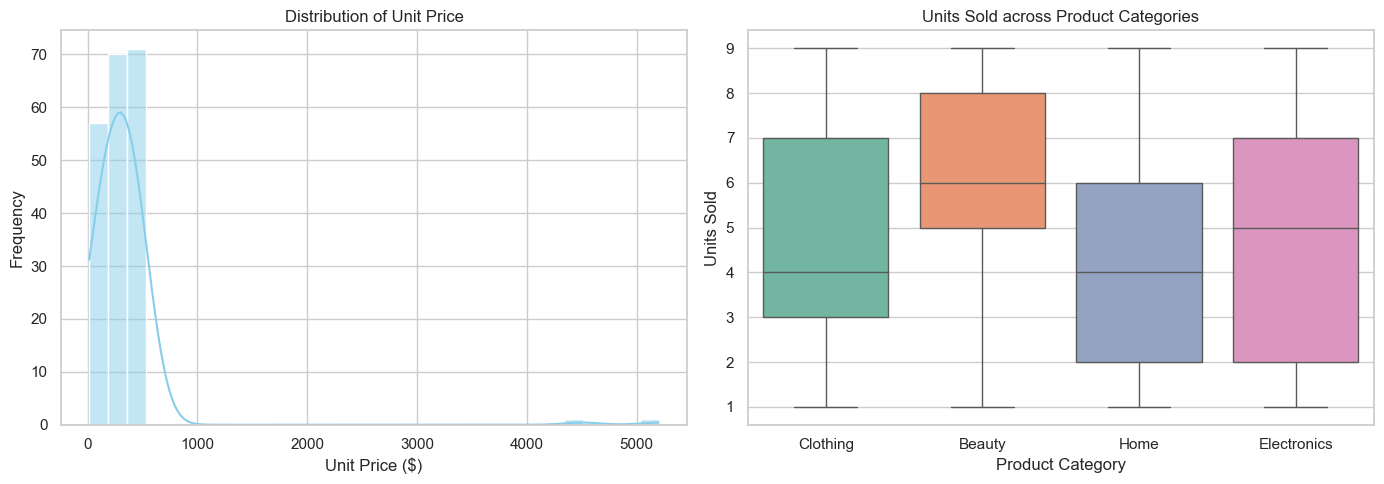


--- VISUALIZATION INSIGHTS ---
Insight 1 (Histogram): The unit price distribution shows that most products are priced under $500. However, the x-axis extends aggressively up to $5000+, visually exposing the heavy right-tail presence of extreme anomalies/outliers.
Insight 2 (Box Plot): Across all item categories, the median units sold hovers consistently around 5 units per transaction. Clothing shows a slightly tighter spread, while Home goods show a broader variance in checkout quantities.


In [4]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# 1. Histogram: Distribution of Unit Prices
plt.subplot(1, 2, 1)
sns.histplot(df['Unit_Price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price ($)')
plt.ylabel('Frequency')

# 2. Box Plot: Units Sold by Product Category
plt.subplot(1, 2, 2)
sns.boxplot(x='Product_Category', y='Units_Sold', data=df, palette='Set2')
plt.title('Units Sold across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

print("\n--- VISUALIZATION INSIGHTS ---")
print("Insight 1 (Histogram): The unit price distribution shows that most products are priced under $500. However, the x-axis extends aggressively up to $5000+, visually exposing the heavy right-tail presence of extreme anomalies/outliers.")
print("Insight 2 (Box Plot): Across all item categories, the median units sold hovers consistently around 5 units per transaction. Clothing shows a slightly tighter spread, while Home goods show a broader variance in checkout quantities.")

In [5]:
print("=== 1. HANDLING MISSING VALUES ===")
# Check for missing values
print(df.isnull().sum())

# Replace missing Store_Rating values with the median
median_rating = df['Store_Rating'].median()
df['Store_Rating'] = df['Store_Rating'].fillna(median_rating)

print("\nMissing values after median replacement:")
print(df.isnull().sum())
print("-" * 50)

print("=== 2. OUTLIER DETECTION AND REMOVAL (IQR) ===")
# Calculate IQR for Unit_Price
Q1 = df['Unit_Price'].quantile(0.25)
Q3 = df['Unit_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Unit_Price'] < lower_bound) | (df['Unit_Price'] > upper_bound)]
print(f"Number of identified outliers: {len(outliers)}")
print(outliers[['Transaction_ID', 'Unit_Price']])

# Filter out outliers to create a cleaned dataset
df_cleaned = df[(df['Unit_Price'] >= lower_bound) & (df['Unit_Price'] <= upper_bound)].copy()

=== 1. HANDLING MISSING VALUES ===
Transaction_ID      0
Product_Category    0
Units_Sold          0
Unit_Price          0
Store_Rating        5
Feedback_Score      0
dtype: int64

Missing values after median replacement:
Transaction_ID      0
Product_Category    0
Units_Sold          0
Unit_Price          0
Store_Rating        0
Feedback_Score      0
dtype: int64
--------------------------------------------------
=== 2. OUTLIER DETECTION AND REMOVAL (IQR) ===
Number of identified outliers: 2
    Transaction_ID  Unit_Price
15            1016      4500.0
87            1088      5200.0


In [6]:
print("=== 3. DATA REDUCTION ===")
# Drop Transaction_ID as it acts as an arbitrary index and lacks analytic relevance
df_reduced = df_cleaned.drop(columns=['Transaction_ID'])
print(f"Columns before reduction: {list(df_cleaned.columns)}")
print(f"Columns after removing Transaction_ID: {list(df_reduced.columns)}")
print("-" * 50)

print("=== 4. DATA SCALING AND DISCRETIZATION ===")
# Min-Max Scaling on Unit_Price to balance scale domains between [0, 1]
min_val = df_reduced['Unit_Price'].min()
max_val = df_reduced['Unit_Price'].max()
df_reduced['Scaled_Unit_Price'] = (df_reduced['Unit_Price'] - min_val) / (max_val - min_val)

# Discretization: Binning Feedback_Score into meaningful categorical tags
bins = [0, 4, 7, 10]
labels = ['Low Performance', 'Average Performance', 'High Performance']
df_reduced['Performance_Tier'] = pd.cut(df_reduced['Feedback_Score'], bins=bins, labels=labels)

print("Modified Dataframe Snapshot showing original data alongside Scaled and Binned outputs:")
df_reduced[['Unit_Price', 'Scaled_Unit_Price', 'Feedback_Score', 'Performance_Tier']].head()

=== 3. DATA REDUCTION ===
Columns before reduction: ['Transaction_ID', 'Product_Category', 'Units_Sold', 'Unit_Price', 'Store_Rating', 'Feedback_Score']
Columns after removing Transaction_ID: ['Product_Category', 'Units_Sold', 'Unit_Price', 'Store_Rating', 'Feedback_Score']
--------------------------------------------------
=== 4. DATA SCALING AND DISCRETIZATION ===
Modified Dataframe Snapshot showing original data alongside Scaled and Binned outputs:


,Unit_Price,Scaled_Unit_Price,Feedback_Score,Performance_Tier
0,403.71,0.801568,10,High Performance
1,148.20,0.274254,8,High Performance
2,96.95,0.168486,6,Average Performance
3,377.80,0.748096,6,Average Performance
4,405.35,0.804953,8,High Performance


In [7]:
print("=== 1. GENERAL OVERVIEW ===")
print(df_reduced.info())

print("\n=== DATA DESCRIPTION ===")
print(df_reduced.describe())

print("\n=== 2. CENTRAL TENDENCY ===")
print(f"Mean Unit Price:   ${df_reduced['Unit_Price'].mean():.2f}")
print(f"Median Unit Price: ${df_reduced['Unit_Price'].median():.2f}")
print(f"Mode Category:      {df_reduced['Product_Category'].mode()[0]}")
print("-" * 50)

print("=== 3. DISPERSION MEASURES ===")
price_range = df_reduced['Unit_Price'].max() - df_reduced['Unit_Price'].min()
print(f"Unit Price Range:    ${price_range:.2f}")
print(f"Unit Price Variance: {df_reduced['Unit_Price'].var():.2f}")
print(f"Unit Price Std Dev:  ${df_reduced['Unit_Price'].std():.2f}")
print("-" * 50)

print("=== 4. CORRELATION ANALYSIS ===")
# Compute correlation matrix for numerical columns
numerical_cols = df_reduced.select_dtypes(include=[np.number])
print(numerical_cols.corr())

=== 1. GENERAL OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
Index: 198 entries, 0 to 199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Product_Category   198 non-null    object  
 1   Units_Sold         198 non-null    int32   
 2   Unit_Price         198 non-null    float64 
 3   Store_Rating       198 non-null    float64 
 4   Feedback_Score     198 non-null    int32   
 5   Scaled_Unit_Price  198 non-null    float64 
 6   Performance_Tier   198 non-null    category
dtypes: category(1), float64(3), int32(2), object(1)
memory usage: 9.6+ KB
None

=== DATA DESCRIPTION ===
       Units_Sold  Unit_Price  Store_Rating  Feedback_Score  Scaled_Unit_Price
count  198.000000  198.000000    198.000000      198.000000         198.000000
mean     4.606061  279.620556      3.651515        5.449495           0.545476
std      2.534305  146.906206      1.078056        2.896694           0.303181
min      1